### **Ollama Setup**

*This sets up Ollama, pulls the models, and provides a robust helper function that can handle real images downloaded from the web.*

In [1]:
# Environment Setup & Server Start

!sudo apt-get update && sudo apt-get install -y zstd

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,705 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,042 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,129 kB]
Get:13 https://r2u.stat.illinois.edu/ubun

In [2]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [3]:
!nohup ollama serve > ollama.log &

nohup: redirecting stderr to stdout


In [4]:
import os, subprocess, time
os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'
subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(10)
print("Ollama server should be ready on http://localhost:11434")

Ollama server should be ready on http://localhost:11434


# Pull Models (Including Vision)

In [5]:
!ollama pull llama3

In [6]:
!ollama pull gemma

In [7]:
!ollama pull llava  # Multimodal vision model required for processing actual images

In [29]:
!ollama pull qwen3.5:0.8b

In [32]:
!ollama pull glm-ocr:q8_0

In [8]:
# Upgraded call_ollama Helper

import requests
import json
import base64

OLLAMA_API_URL = "http://localhost:11434/api/generate"

In [9]:
def call_ollama(prompt, model="llama3", stream=False, images=None):
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": stream
    }

    # Attach base64 encoded image list if provided
    if images:
        payload["images"] = images

    resp = requests.post(OLLAMA_API_URL, json=payload)
    if resp.status_code != 200:
        raise RuntimeError(f"Request failed: {resp.status_code}, {resp.text}")

    if stream:
        for line in resp.text.splitlines():
            if not line.strip():
                continue
            obj = json.loads(line)
            print(obj.get("response", ""), end="")
    else:
        data = resp.json()
        return data.get("response", "")

In [10]:
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

### **1: Visual AI - Real Receipt/Invoice Extraction**

**Concept:** Instead of OCR, we download an actual, real-world sample receipt image used in the [H2oGPT open-source testing repository](https://www.google.com/search?q=https://raw.githubusercontent.com/h2oai/h2ogpt/main/tests/receipt.jpg) and use the Vision LLM (`glm-ocr:q8_0`) to extract structured data.


In [11]:
# Fetch a Real Receipt Image

import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

In [12]:
# Fetching an actual sample receipt used in AI vision testing
image_url = "https://raw.githubusercontent.com/h2oai/h2ogpt/main/tests/receipt.jpg"
image_path = "real_receipt.jpg"
urllib.request.urlretrieve(image_url, image_path)

('real_receipt.jpg', <http.client.HTTPMessage at 0x7eef35039910>)

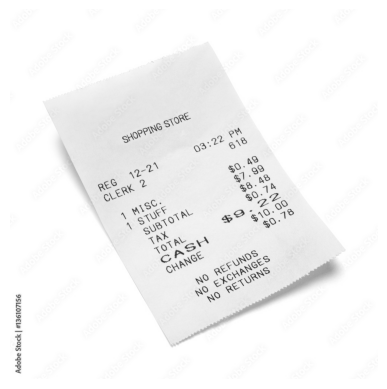

In [13]:
# Display the downloaded real-world image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [14]:
# CELL 5: Multimodal Extraction using glm-ocr:q8_0

base64_image = encode_image_to_base64(image_path)

In [15]:
prompt = """
You are an expert financial data extraction AI.
Analyze this real-world receipt image and extract the data into a strict JSON format.
Attempt to find keys for: MerchantName, Date, TotalAmount, and LineItems (if readable).
If a value is blurry or missing, put "null". Return ONLY valid JSON.
"""

In [33]:
print("Processing real receipt image with glm-ocr:q8_0...\n")
result = call_ollama(prompt=prompt, model="glm-ocr:q8_0", images=[base64_image])
print(result)

Processing real receipt image with glm-ocr:q8_0...

1. The price trend over the 10-day period shows a slight increase in the Close price from $36.89 to $37.53, indicating a moderate upward momentum.
2. There are no significant anomalies in the trading Volume; it remains relatively stable throughout the period.
3. A concise summary: The stock price has shown a slight increase over the last 10 days, with a peak at $37.53 and a trough at $36.89. The volume is consistent throughout this period, indicating no significant trading activity.
This image shows a receipt from a General Electric store. It includes the following details:

- REG: 12-21
- CLERK: 2
- MISC.: $0.49
- STUFF: $7.99
- SUBTOTAL: $8.48
- TAX: $0.74
- TOTAL: $9.22
- CASH: $10.00
- CHANGE: $0.78

No refunds, no exchanges, and no returns.

This information is crucial for understanding the financial status of the transaction.


### **2: Document Intelligence - Real Financial Stock Data**

**Concept:** Parsing actual historic financial stock data. We will pull General Electric's (GE) historical stock market CSV directly from [Scikit-learn's Example Data repository](https://www.google.com/search?q=https://raw.githubusercontent.com/scikit-learn/examples-data/master/financial-data/GE.csv).

In [17]:
# Fetch Real Tabular Financial Data

!pip install pandas tabulate -q

In [18]:
import pandas as pd

# Fetching real historical stock data (GE) from public ML datasets
csv_url = "https://raw.githubusercontent.com/scikit-learn/examples-data/master/financial-data/GE.csv"
df = pd.read_csv(csv_url)

In [19]:
# Display the real data structure (Date, Open, High, Low, Close, Volume)
print("Real Financial Data Sample (GE Stock):")
print(df.head())

Real Financial Data Sample (GE Stock):
         date   open  close
0  2003-01-02  24.65  25.48
1  2003-01-03  25.35  25.40
2  2003-01-06  25.40  26.05
3  2003-01-07  25.99  25.90
4  2003-01-08  25.85  25.50


In [20]:
# To respect context windows, we will pass a subset (e.g., the last 10 days of the dataset)
# to the LLM formatted as markdown
recent_data = df.tail(10)
markdown_table = recent_data.to_markdown(index=False)

In [21]:
# Reasoning over Real Tabular Data with Llama3

prompt = f"""
You are a Senior Financial Analyst.
Review the following table of recent historical stock data (Open, High, Low, Close, Volume) for General Electric:

{markdown_table}

Tasks:
1. Analyze the price trend (Close price) over this specific 10-day period. Are we seeing an upward or downward momentum?
2. Note any significant anomalies in the trading Volume.
3. Provide a concise, professional 1-paragraph summary.
"""

In [22]:
print("\n--- Llama3 Financial Analysis (Real Data) ---\n")
analysis = call_ollama(prompt=prompt, model="llama3", stream=True)


--- Llama3 Financial Analysis (Real Data) ---

As a Senior Financial Analyst, I've reviewed the historical stock data for General Electric from December 17th to 31st, 2007.

**Price Trend Analysis:**
The close price trend over this 10-day period shows an overall upward momentum. The prices have generally increased, with only one day (December 27th) experiencing a slight decline. This upward trend is characterized by a steady increase in the close prices, with no significant pullbacks or corrections.

**Volume Anomalies:**
Upon reviewing the volume data, I've noted that there was a relatively high trading volume on December 21st, which might be an indication of increased investor interest or market reaction to some news event. Additionally, the volume remained elevated on December 24th and 26th, which could be a sign of ongoing market activity.

**Summary:**
Over this 10-day period, General Electric's stock price has demonstrated a steady upward trend, indicating positive momentum for 

### **3: End-to-End Application - Automated Auditing**

**Concept:** Bringing it together. We combine a text-based corporate policy rule with the actual receipt image downloaded to simulate a cross-modal, agentic auditing task.

In [23]:
# The Cross-Modal Auditing Workflow

# Re-using the actual receipt image from Notebook 1
base64_image = encode_image_to_base64("real_receipt.jpg")

In [24]:
# Simulating internal text-based constraints to cross-reference against the visual image
financial_policy = """
CORPORATE EXPENSE POLICY (Effective 2026):
1. Any dining, restaurant, or food receipt exceeding $20.00 requires a manager's justification note.
2. Receipts under $20.00 can be "AUTO-APPROVED".
3. Taxes must be explicitly visible on the receipt to claim compliance.
"""

In [25]:
audit_prompt = f"""
You are an AI Auditing Agent. You must review the attached real-world receipt image against the corporate policy below.

{financial_policy}

Task:
1. Read the Total Amount from the attached receipt image.
2. Determine if taxes are listed on this receipt.
3. Cross-reference this with the Corporate Expense Policy.
4. State clearly whether this receipt can be "AUTO-APPROVED" or if it requires a "MANAGER NOTE".
5. Explain your reasoning based strictly on the image and the policy.
"""

In [34]:
print("Running Cross-Modal Audit (glm-ocr:q8_0 on Real Image)...\n")
audit_decision = call_ollama(prompt=audit_prompt, model="glm-ocr:q8_0", images=[base64_image])
print(audit_decision)

Running Cross-Modal Audit (glm-ocr:q8_0 on Real Image)...

1. The Total Amount is $9.22.
2. Taxes are listed as $0.74.
3. Yes, taxes are listed on this receipt.
4. This receipt cannot be "AUTO-APPROVED" because it does not include tax information.
5. According to the Corporate Expense Policy, any dining, restaurant, or food receipt exceeding $20.00 requires a manager's justification note. Since taxes are listed on this receipt, it is not an exception to the policy.
The image shows a receipt from a shopping store. The text on the receipt includes:

SHOPPING STORE

REG 12-21 03:22 PM
CLERK 2
1 MISC.
1 STUFF
SUBTOTAL $8.48
TAX $0.74
TOTAL $9.22
CASH $10.00
CHANGE $0.78

No refunds
No exchanges
No returns

The Corporate Expense Policy states:

1. Any dining, restaurant, or food receipt exceeding $20.00 requires a manager's justification note.
2. Receipts under $20.00 can be "AUTO-APPROVED".
3. Taxes must be explicitly visible on the receipt to claim compliance.

Based on this information, 